In [ ]:
# link drive https://drive.google.com/drive/folders/1C4WJGt3bhrcQ-FtFIm2m_ZYwhYCb7GjL?usp=sharing

"""
platform google colab

unduh menggunakan import gdown tanpa mount drive
folder drive isinya:
1. cropped_columns.csv (file dataset ori udah dipilih kolomnya) https://drive.google.com/file/d/1hDsIPTczoKG79wGMsYaA9EJzL2qKrUgl/view?usp=drive_link
2. test_scaled_rs42.csv https://drive.google.com/file/d/1mUnx_jQ0qu1ZVhHTGJ0qNUZGY6iFluo5/view?usp=drive_link
3. test_scaled_rs123.csv https://drive.google.com/file/d/1tiJwQt3A2L0gZFXaNj-V3EquPH1jNJ11/view?usp=drive_link
4. test_scaled_rs456.csv https://drive.google.com/file/d/1LMWKha9aKzF2ZEvGvbc5rfmljSx55moh/view?usp=drive_link
5. test_scaled_rs789.csv https://drive.google.com/file/d/1u6zEuSL7Y746AJpmQfZfiVNBAvnMOmf6/view?usp=drive_link
6. test_scaled_rs999.csv https://drive.google.com/file/d/1v3tvyKrAb7SexO1hHDpnK9LUXeEFTTfK/view?usp=drive_link
7. train_smote.csv https://drive.google.com/file/d/17bQhKTuMK3kUgx5fSnn_xjKFdtjIFkPh/view?usp=drive_link
8. train_smotetomek.csv https://drive.google.com/file/d/1TS4EGCjlwS-H493YBH1KHpQ9gD5FXcVx/view?usp=drive_link

buat model menggunakan:
1. multi later perceptron, latih menggunakan train_smote.csv lalu test dengan 5 test file
2. multi later perceptron, latih menggunakan train_smotetomek.csv lalu test dengan 5 test file
3. random forest, latih menggunakan train_smote.csv lalu test dengan 5 test file
4. random forest, latih menggunakan train_smotetomek.csv lalu test dengan 5 test file

evaluasi menggunakan confusion matrix dan accuracy score

buat cell secara berurutan
"""

'\nplatform google colab\n\nunduh menggunakan import gdown tanpa mount drive\nfolder drive isinya:\n1. cropped_columns.csv (file dataset ori udah dipilih kolomnya) https://drive.google.com/file/d/1hDsIPTczoKG79wGMsYaA9EJzL2qKrUgl/view?usp=drive_link\n2. test_scaled_rs42.csv https://drive.google.com/file/d/1mUnx_jQ0qu1ZVhHTGJ0qNUZGY6iFluo5/view?usp=drive_link\n3. test_scaled_rs123.csv https://drive.google.com/file/d/1tiJwQt3A2L0gZFXaNj-V3EquPH1jNJ11/view?usp=drive_link\n4. test_scaled_rs456.csv https://drive.google.com/file/d/1LMWKha9aKzF2ZEvGvbc5rfmljSx55moh/view?usp=drive_link\n5. test_scaled_rs789.csv https://drive.google.com/file/d/1u6zEuSL7Y746AJpmQfZfiVNBAvnMOmf6/view?usp=drive_link\n6. test_scaled_rs999.csv https://drive.google.com/file/d/1v3tvyKrAb7SexO1hHDpnK9LUXeEFTTfK/view?usp=drive_link\n7. train_smote.csv https://drive.google.com/file/d/17bQhKTuMK3kUgx5fSnn_xjKFdtjIFkPh/view?usp=drive_link\n8. train_smotetomek.csv https://drive.google.com/file/d/1TS4EGCjlwS-H493YBH1KHpQ9gD5

In [ ]:
# CELL 1 - Install & Import Library
# !pip install gdown -q

import gdown
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CELL 2 - Download semua file dari Google Drive
# Daftar file (file-id diambil dari link "view")
file_ids = {
    "cropped_columns.csv"      : "1hDsIPTczoKG79wGMsYaA9EJzL2qKrUgl",
    "test_scaled_rs42.csv"     : "1mUnx_jQ0qu1ZVhHTGJ0qNUZGY6iFluo5",
    "test_scaled_rs123.csv"    : "1tiJwQt3A2L0gZFXaNj-V3EquPH1jNJ11",
    "test_scaled_rs456.csv"    : "1LMWKha9aKzF2ZEvGvbc5rfmljSx55moh",
    "test_scaled_rs789.csv"    : "1u6zEuSL7Y746AJpmQfZfiVNBAvnMOmf6",
    "test_scaled_rs999.csv"    : "1v3tvyKrAb7SexO1hHDpnK9LUXeEFTTfK",
    "train_smote.csv"          : "17bQhKTuMK3kUgx5fSnn_xjKFdtjIFkPh",
    "train_smotetomek.csv"     : "1TS4EGCjlwS-H493YBH1KHpQ9gD5FXcVx"
}

for nama, fid in file_ids.items():
    url = f"https://drive.google.com/uc?id={fid}"
    gdown.download(url, nama, quiet=False)
    print(f"{nama} → selesai di-download\n")

Downloading...
From: https://drive.google.com/uc?id=1hDsIPTczoKG79wGMsYaA9EJzL2qKrUgl
To: /content/cropped_columns.csv
100%|██████████| 7.88M/7.88M [00:00<00:00, 22.3MB/s]


cropped_columns.csv → selesai di-download



Downloading...
From: https://drive.google.com/uc?id=1mUnx_jQ0qu1ZVhHTGJ0qNUZGY6iFluo5
To: /content/test_scaled_rs42.csv
100%|██████████| 6.17M/6.17M [00:00<00:00, 28.9MB/s]


test_scaled_rs42.csv → selesai di-download



Downloading...
From: https://drive.google.com/uc?id=1tiJwQt3A2L0gZFXaNj-V3EquPH1jNJ11
To: /content/test_scaled_rs123.csv
100%|██████████| 6.17M/6.17M [00:00<00:00, 31.3MB/s]


...

test_scaled_rs999.csv → selesai di-download



Downloading...
From: https://drive.google.com/uc?id=17bQhKTuMK3kUgx5fSnn_xjKFdtjIFkPh
To: /content/train_smote.csv
100%|██████████| 43.7M/43.7M [00:00<00:00, 51.8MB/s]


train_smote.csv → selesai di-download



Downloading...
From: https://drive.google.com/uc?id=1TS4EGCjlwS-H493YBH1KHpQ9gD5FXcVx
To: /content/train_smotetomek.csv
100%|██████████| 43.1M/43.1M [00:01<00:00, 33.7MB/s]


train_smotetomek.csv → selesai di-download



In [ ]:
# CELL 3 - Baca semua dataset
df_cropped   = pd.read_csv("cropped_columns.csv")
train_smote  = pd.read_csv("train_smote.csv")
train_smotet = pd.read_csv("train_smotetomek.csv")

test_files = [
    "test_scaled_rs42.csv",
    "test_scaled_rs123.csv",
    "test_scaled_rs456.csv",
    "test_scaled_rs789.csv",
    "test_scaled_rs999.csv"
]

test_dfs = {f.split('_')[2]: pd.read_csv(f) for f in test_files}

# Pastikan kolom target adalah yang terakhir (biasanya 'class' atau 'target')
# Sesuaikan nama kolom target jika berbeda
target_col = train_smote.columns[-1]   # asumsi kolom terakhir = label

print("Target column :", target_col)
print("Shape train SMOTE      :", train_smote.shape)
print("Shape train SMOTETomek :", train_smotet.shape)
for name, df in test_dfs.items():
    print(f"Shape test {name}      :", df.shape)

Target column : Default
Shape train SMOTE      : (361110, 7)
Shape train SMOTETomek : (356468, 7)
Shape test rs42.csv      : (51070, 7)
Shape test rs123.csv      : (51070, 7)
Shape test rs456.csv      : (51070, 7)
Shape test rs789.csv      : (51070, 7)
Shape test rs999.csv      : (51070, 7)


In [ ]:
# CELL 4 - Persiapan X dan y
X_train_smote  = train_smote.drop(columns=[target_col])
y_train_smote  = train_smote[target_col]

X_train_smotet = train_smotet.drop(columns=[target_col])
y_train_smotet = train_smotet[target_col]

# Fungsi untuk evaluasi pada semua test set
def evaluate_model(model, model_name, X_train, y_train):
    print(f"\n{'='*60}")
    print(f" TRAINING {model_name}")
    print(f"{'='*60}")
    model.fit(X_train, y_train)

    results = []
    for name, df_test in test_dfs.items():
        X_test = df_test.drop(columns=[target_col])
        y_test = df_test[target_col]

        y_pred = model.predict(X_test)
        acc    = accuracy_score(y_test, y_pred)
        cm     = confusion_matrix(y_test, y_pred)

        print(f"\n>>> Test set: {name}")
        print(f"Accuracy : {acc:.4f}")
        print("Confusion Matrix:\n", cm)

        results.append((name, acc, cm))

    return results

In [ ]:
# CELL 5 - 1. MLP + SMOTE
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

evaluate_model(mlp, "MLPClassifier + train_smote.csv", X_train_smote, y_train_smote)


 TRAINING MLPClassifier + train_smote.csv

>>> Test set: rs42.csv
Accuracy : 0.6458
Confusion Matrix:
 [[29688 15451]
 [ 2638  3293]]

>>> Test set: rs123.csv
Accuracy : 0.6826
Confusion Matrix:
 [[30755 14384]
 [ 1826  4105]]

>>> Test set: rs456.csv
Accuracy : 0.6784
Confusion Matrix:
 [[30552 14587]
 [ 1838  4093]]

>>> Test set: rs789.csv
Accuracy : 0.6789
Confusion Matrix:
 [[30542 14597]
 [ 1804  4127]]

>>> Test set: rs999.csv
Accuracy : 0.6802
Confusion Matrix:
 [[30653 14486]
 [ 1847  4084]]


[('rs42.csv',
  0.6457998825141962,
  array([[29688, 15451],
         [ 2638,  3293]])),
 ('rs123.csv',
  0.6825925200704915,
  array([[30755, 14384],
         [ 1826,  4105]])),
 ('rs456.csv',
  0.6783826121010378,
  array([[30552, 14587],
         [ 1838,  4093]])),
 ('rs789.csv',
  0.6788525553162327,
  array([[30542, 14597],
         [ 1804,  4127]])),
 ('rs999.csv',
  0.680184061092618,
  array([[30653, 14486],
         [ 1847,  4084]]))]

In [ ]:
# CELL 6 - 2. MLP + SMOTETomek
mlp2 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

evaluate_model(mlp2, "MLPClassifier + train_smotetomek.csv", X_train_smotet, y_train_smotet)


 TRAINING MLPClassifier + train_smotetomek.csv

>>> Test set: rs42.csv
Accuracy : 0.6438
Confusion Matrix:
 [[29674 15465]
 [ 2728  3203]]

>>> Test set: rs123.csv
Accuracy : 0.6771
Confusion Matrix:
 [[30527 14612]
 [ 1876  4055]]

>>> Test set: rs456.csv
Accuracy : 0.6767
Confusion Matrix:
 [[30528 14611]
 [ 1901  4030]]

>>> Test set: rs789.csv
Accuracy : 0.6744
Confusion Matrix:
 [[30466 14673]
 [ 1956  3975]]

>>> Test set: rs999.csv
Accuracy : 0.6774
Confusion Matrix:
 [[30558 14581]
 [ 1894  4037]]


[('rs42.csv',
  0.6437634619150187,
  array([[29674, 15465],
         [ 2728,  3203]])),
 ('rs123.csv',
  0.6771490111611513,
  array([[30527, 14612],
         [ 1876,  4055]])),
 ('rs456.csv',
  0.6766790679459566,
  array([[30528, 14611],
         [ 1901,  4030]])),
 ('rs789.csv',
  0.6743880947718818,
  array([[30466, 14673],
         [ 1956,  3975]])),
 ('rs999.csv',
  0.6774035637360486,
  array([[30558, 14581],
         [ 1894,  4037]]))]

In [ ]:
# CELL 7 - 3. Random Forest + SMOTE
rf1 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

evaluate_model(rf1, "RandomForest + train_smote.csv", X_train_smote, y_train_smote)


 TRAINING RandomForest + train_smote.csv

>>> Test set: rs42.csv
Accuracy : 0.8419
Confusion Matrix:
 [[41716  3423]
 [ 4652  1279]]

>>> Test set: rs123.csv
Accuracy : 0.9689
Confusion Matrix:
 [[44468   671]
 [  918  5013]]

>>> Test set: rs456.csv
Accuracy : 0.9687
Confusion Matrix:
 [[44489   650]
 [  948  4983]]

>>> Test set: rs789.csv
Accuracy : 0.9687
Confusion Matrix:
 [[44436   703]
 [  895  5036]]

>>> Test set: rs999.csv
Accuracy : 0.9690
Confusion Matrix:
 [[44470   669]
 [  913  5018]]


[('rs42.csv',
  0.8418836890542393,
  array([[41716,  3423],
         [ 4652,  1279]])),
 ('rs123.csv',
  0.9688858429606423,
  array([[44468,   671],
         [  918,  5013]])),
 ('rs456.csv',
  0.9687096142549442,
  array([[44489,   650],
         [  948,  4983]])),
 ('rs789.csv',
  0.9687096142549442,
  array([[44436,   703],
         [  895,  5036]])),
 ('rs999.csv',
  0.9690229097317408,
  array([[44470,   669],
         [  913,  5018]]))]

In [ ]:
# CELL 8 - 4. Random Forest + SMOTETomek
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

evaluate_model(rf2, "RandomForest + train_smotetomek.csv", X_train_smotet, y_train_smotet)


 TRAINING RandomForest + train_smotetomek.csv

>>> Test set: rs42.csv
Accuracy : 0.8413
Confusion Matrix:
 [[41669  3470]
 [ 4633  1298]]

>>> Test set: rs123.csv
Accuracy : 0.9667
Confusion Matrix:
 [[44369   770]
 [  930  5001]]

>>> Test set: rs456.csv
Accuracy : 0.9665
Confusion Matrix:
 [[44394   745]
 [  966  4965]]

>>> Test set: rs789.csv
Accuracy : 0.9663
Confusion Matrix:
 [[44340   799]
 [  923  5008]]

>>> Test set: rs999.csv
Accuracy : 0.9659
Confusion Matrix:
 [[44340   799]
 [  940  4991]]


[('rs42.csv',
  0.8413354219698453,
  array([[41669,  3470],
         [ 4633,  1298]])),
 ('rs123.csv',
  0.9667123555903662,
  array([[44369,   770],
         [  930,  5001]])),
 ('rs456.csv',
  0.9664969649500685,
  array([[44394,   745],
         [  966,  4965]])),
 ('rs789.csv',
  0.9662815743097709,
  array([[44340,   799],
         [  923,  5008]])),
 ('rs999.csv',
  0.9659486978656746,
  array([[44340,   799],
         [  940,  4991]]))]

In [ ]:
# CELL 9 - Ringkasan Akurasi (opsional)
print("\n" + "="*70)
print("RINGKASAN AKURASI".center(70))
print("="*70)
models = [
    ("MLP + SMOTE"      , mlp),
    ("MLP + SMOTETomek" , mlp2),
    ("RF  + SMOTE"      , rf1),
    ("RF  + SMOTETomek" , rf2)
]

for desc, model in models:
    print(f"\n{desc}")
    for name, df_test in test_dfs.items():
        X_test = df_test.drop(columns=[target_col])
        y_test = df_test[target_col]
        acc = accuracy_score(y_test, model.predict(X_test))
        print(f"   {name:12} → {acc:.4f}")


                          RINGKASAN AKURASI                           

MLP + SMOTE
   rs42.csv     → 0.6458
   rs123.csv    → 0.6826
   rs456.csv    → 0.6784
   rs789.csv    → 0.6789
   rs999.csv    → 0.6802

MLP + SMOTETomek
   rs42.csv     → 0.6438
   rs123.csv    → 0.6771
   rs456.csv    → 0.6767
   rs789.csv    → 0.6744
   rs999.csv    → 0.6774

RF  + SMOTE
   rs42.csv     → 0.8419
   rs123.csv    → 0.9689
   rs456.csv    → 0.9687
   rs789.csv    → 0.9687
   rs999.csv    → 0.9690

RF  + SMOTETomek
   rs42.csv     → 0.8413
   rs123.csv    → 0.9667
   rs456.csv    → 0.9665
   rs789.csv    → 0.9663
   rs999.csv    → 0.9659


Fitur yang digunakan: ['Income', 'Age', 'LoanAmount', 'LoanTerm', 'DTIRatio', 'CreditScore']

                FEATURE IMPORTANCE RINGKASAN (6 Fitur)                

1. Random Forest + SMOTE


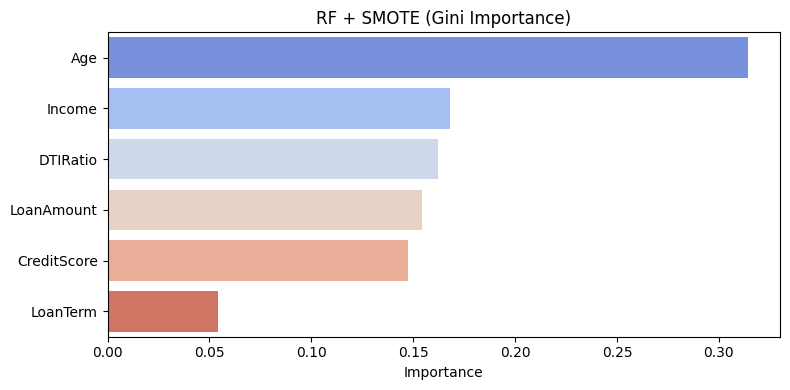


2. Random Forest + SMOTETomek


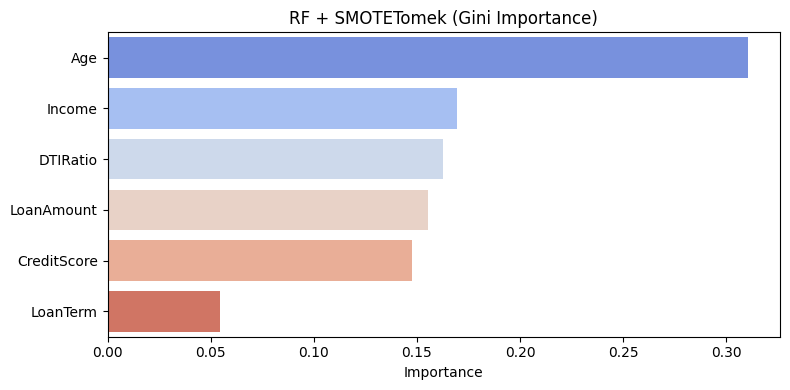


3. MLP + SMOTE


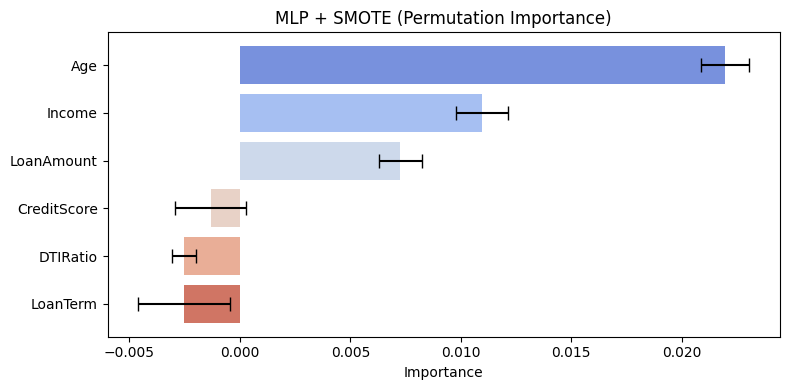


4. MLP + SMOTETomek


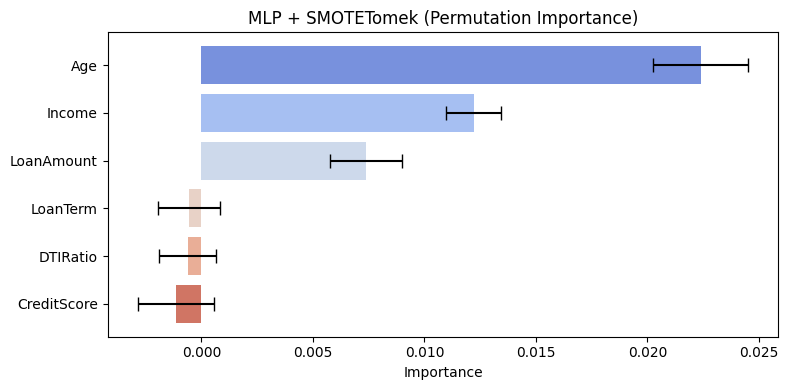


Tabel Ringkasan Importance (Urutan RF + SMOTE)


,Fitur,RF + SMOTE,RF + SMOTETomek,MLP + SMOTE,MLP + SMOTETomek
1,Age,0.3143,0.3106,0.0220,0.0224
0,Income,0.1680,0.1693,0.0110,0.0122
4,DTIRatio,0.1620,0.1626,-0.0025,-0.0006
2,LoanAmount,0.1541,0.1552,0.0073,0.0074
5,CreditScore,0.1476,0.1477,-0.0013,-0.0011
3,LoanTerm,0.0540,0.0546,-0.0025,-0.0006


In [ ]:
# CELL RINGKAS - Feature Importance untuk Semua Model (Hanya 6 Fitur)

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Nama fitur (hanya 6)
feature_names = X_train_smote.columns.tolist()
print("Fitur yang digunakan:", feature_names)
print("\n" + "="*70)
print("FEATURE IMPORTANCE RINGKASAN (6 Fitur)".center(70))
print("="*70)

# Fungsi plot sederhana untuk 6 fitur
def plot_importance(values, title, std=None):
    indices = np.argsort(values)[::-1]
    sorted_features = [feature_names[i] for i in indices]
    sorted_values = values[indices]

    plt.figure(figsize=(8, 4))
    # Plot bars without xerr first to avoid the internal matplotlib error
    ax = sns.barplot(x=sorted_values, y=sorted_features, palette="coolwarm")
    plt.title(title)
    plt.xlabel("Importance")

    if std is not None:
        sorted_std = std[indices]
        # Add error bars manually using plt.errorbar
        y_pos = np.arange(len(sorted_features)) # y-coordinates for horizontal bars are their indices
        ax.errorbar(x=sorted_values, y=y_pos, xerr=sorted_std, fmt='none', ecolor='black', capsize=5)

    plt.tight_layout()
    plt.show()

# Gunakan salah satu test set untuk permutation (rs42 sebagai contoh)
X_test = test_dfs['rs42.csv'].drop(columns=[target_col])
y_test = test_dfs['rs42.csv'][target_col]

# 1. Random Forest + SMOTE
print("\n1. Random Forest + SMOTE")
rf1_imp = rf1.feature_importances_
plot_importance(rf1_imp, "RF + SMOTE (Gini Importance)")

# 2. Random Forest + SMOTETomek
print("\n2. Random Forest + SMOTETomek")
rf2_imp = rf2.feature_importances_
plot_importance(rf2_imp, "RF + SMOTETomek (Gini Importance)")

# 3. MLP + SMOTE (Permutation Importance)
print("\n3. MLP + SMOTE")
perm_mlp1 = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
plot_importance(perm_mlp1.importances_mean, "MLP + SMOTE (Permutation Importance)", perm_mlp1.importances_std)

# 4. MLP + SMOTETomek (Permutation Importance)
print("\n4. MLP + SMOTETomek")
perm_mlp2 = permutation_importance(mlp2, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
plot_importance(perm_mlp2.importances_mean, "MLP + SMOTETomek (Permutation Importance)", perm_mlp2.importances_std)

# Tabel perbandingan singkat (opsional)
print("\nTabel Ringkasan Importance (Urutan RF + SMOTE)")
df_importance = pd.DataFrame({
    'Fitur': feature_names,
    'RF + SMOTE': rf1.feature_importances_,
    'RF + SMOTETomek': rf2.feature_importances_,
    'MLP + SMOTE': perm_mlp1.importances_mean,
    'MLP + SMOTETomek': perm_mlp2.importances_mean
}).sort_values(by='RF + SMOTE', ascending=False).round(4)

display(df_importance)